# Dedicated Serving Frameworks — TorchServe and TF Serving

Raw FastAPI works well for a single model. When you have dozens of models, need GPU batching, or want built-in versioning and metrics, dedicated serving frameworks like TorchServe and TensorFlow Serving add those capabilities out of the box.

**Note:** TorchServe and TF Serving run as external processes, not inside a Jupyter kernel. This notebook shows the exact files and commands with clear explanations of what each does. Run the shell commands in a terminal.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 02 "Model Serving (TensorFlow Serving / TorchServe)" — that lesson saved a TorchScript artifact and explained why a dedicated serving stack exists; here you write the handler, the archive and the config files those servers actually consume.


## 📰 TorchServe was archived on 7 August 2025

The `pytorch/serve` repository on GitHub now opens with a notice: *"This project is no longer actively maintained. While existing releases remain available, there are no planned updates, bug fixes, new features, or security patches. Users should be aware that vulnerabilities may not be addressed."* The repository was **archived on 7 August 2025** and is read-only.

That is not a footnote to this lesson — it is the lesson. TorchServe was PyTorch's official serving system, built by AWS and Meta, and teams built production stacks on it. Its handler API, `.mar` archives and `config.properties` are still the clearest way to learn what a dedicated serving framework *does*: batching, multi-model hosting, versioned loading, Prometheus metrics. But **choosing a serving framework is choosing a dependency you cannot easily leave**, and the maintenance status of that dependency is a first-class selection criterion, not something you check afterwards.

**What goes wrong without this lesson.** Without a serving framework, teams re-implement request batching, model versioning and metrics inside their own FastAPI app — badly, three times, in three services. With the wrong one, they inherit an unpatched attack surface and a migration project. The 2025 survey of 25 inference engines (arXiv 2505.01658) exists because this decision is now genuinely hard and genuinely consequential.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain what serving frameworks add over raw FastAPI (batching, versioning, metrics, GPU)
2. Describe the TorchServe workflow: save model, write handler, archive, serve
3. Write a custom TorchServe handler with `preprocess`, `inference`, `postprocess`
4. Save a Keras model in SavedModel format and describe the TF Serving Docker workflow
5. Decide when a dedicated serving framework is worth its complexity

## 1. What Serving Frameworks Add

| Feature | Raw FastAPI | TorchServe / TF Serving |
|---|---|---|
| Request batching | Manual | Built-in (configurable batch size + timeout) |
| Model versioning | Manual | Built-in (load multiple versions simultaneously) |
| GPU support | Manual | Built-in (automatic GPU batching) |
| Metrics | Manual | Built-in (Prometheus endpoints) |
| A/B testing | Manual | Built-in (traffic splitting between versions) |
| gRPC support | Need grpcio | Built-in |

Use a serving framework when: you have >5 models, you need GPU batching, or you need built-in metrics for SLAs.

## Part 1 — TorchServe

TorchServe is PyTorch's official serving system, developed by AWS and Facebook. The workflow:
1. Train and save the model with `torch.save`
2. Write a **handler** class that knows how to pre/post-process requests
3. Package model + handler into a `.mar` archive with `torch-model-archiver`
4. Start TorchServe and use the management API

### Step 1 — Train and Save a PyTorch Model

In [1]:
# WHAT: train a tiny 2-layer PyTorch classifier on iris and save its state_dict.
# WHY: TorchServe packages a trained model file — we need a real artifact before
# we can build the handler and archive around it.
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train a simple 2-layer network on Iris
iris = load_iris()
scaler = StandardScaler()
X = scaler.fit_transform(iris.data).astype(np.float32)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4 inputs -> 32 hidden -> 3 class logits: small enough to train in seconds.
model = nn.Sequential(
    nn.Linear(4, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

Xt = torch.tensor(X_train)
Yt = torch.tensor(y_train, dtype=torch.long)

# Standard training loop: zero grads, forward, loss, backward, update.
for epoch in range(200):
    optimizer.zero_grad()
    loss = loss_fn(model(Xt), Yt)
    loss.backward()
    optimizer.step()

# Switch to eval mode and score the holdout set without tracking gradients.
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_test)).argmax(dim=1).numpy()
    acc = (preds == y_test).mean()
print(f"Test accuracy: {acc:.2%}")

# state_dict saves WEIGHTS only — the architecture must be shipped as code (next cell).
# Save state dict
MODEL_PT = "/tmp/iris_torchserve.pt"
torch.save(model.state_dict(), MODEL_PT)
print(f"Model saved: {MODEL_PT}")

Test accuracy: 100.00%
Model saved: /tmp/iris_torchserve.pt


### Step 2 — Write the Model Definition File

TorchServe needs a Python file that defines the model architecture (so it can reconstruct the network before loading the state dict).

In [2]:
%%writefile /tmp/iris_model_def.py
# WHAT: write the model architecture as a standalone Python file.
# WHY: TorchServe rebuilds the network from this class then loads the saved
# weights into it — the .pt file alone does not know its own architecture.
import torch.nn as nn

class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

Overwriting /tmp/iris_model_def.py


### Step 3 — Write the Handler

The handler is the core of TorchServe customization. It has three methods:
- `preprocess(data)`: convert raw HTTP body → model-ready tensors
- `inference(data)`: run `model.forward()` — TorchServe batches this automatically
- `postprocess(data)`: convert tensors → JSON-serializable response

In [3]:
%%writefile /tmp/iris_handler.py
# WHAT: write the TorchServe handler — the glue between HTTP requests and the model.
# WHY: preprocess/inference/postprocess is TorchServe's serving contract; batching
# happens automatically between these hooks, which is where the speed comes from.
import json
import torch
import numpy as np
from ts.torch_handler.base_handler import BaseHandler

CLASSES = ["setosa", "versicolor", "virginica"]

class IrisHandler(BaseHandler):
    """TorchServe handler for the Iris classifier."""

    # Step 1: raw HTTP bodies -> one batched float tensor.
    def preprocess(self, data):
        """
        Convert raw HTTP request body to a tensor.
        Expects JSON: {"sepal_length": 5.1, "sepal_width": 3.5,
                       "petal_length": 1.4, "petal_width": 0.2}
        """
        inputs = []
        for row in data:
            body = json.loads(row["body"])
            features = [
                body["sepal_length"], body["sepal_width"],
                body["petal_length"], body["petal_width"]
            ]
            inputs.append(features)
        # Returns a batched tensor — TorchServe may send multiple requests at once
        return torch.tensor(inputs, dtype=torch.float32)

    # Step 2: the forward pass, with softmax to turn logits into probabilities.
    def inference(self, data):
        """
        Run the model forward pass.
        TorchServe automatically batches concurrent requests here.
        """
        with torch.no_grad():
            logits = self.model(data)
            probs  = torch.softmax(logits, dim=1)
        return probs

    # Step 3: tensor -> JSON-friendly dicts, one per request in the batch.
    def postprocess(self, data):
        """
        Convert the probability tensor to a list of JSON-serializable dicts.
        One dict per request in the batch.
        """
        results = []
        for prob_row in data:
            class_id = prob_row.argmax().item()
            results.append({
                "prediction": CLASSES[class_id],
                "class_id": class_id,
                "confidence": round(prob_row.max().item(), 3)
            })
        return results

Overwriting /tmp/iris_handler.py


### Step 4 — Create the Model Archive (.mar) and Serve

TorchServe packages everything into a `.mar` (Model ARchive) file. Run these commands in a terminal after `pip install torchserve torch-model-archiver`.

In [4]:
# These are shell commands — run them in a terminal, not in the notebook

torchserve_commands = """
# 1. Create the model archive
torch-model-archiver \\
    --model-name iris \\
    --version 1.0 \\
    --model-file /tmp/iris_model_def.py \\
    --serialized-file /tmp/iris_torchserve.pt \\
    --handler /tmp/iris_handler.py \\
    --export-path /tmp/model_store
# Output: /tmp/model_store/iris.mar

# 2. Start TorchServe
torchserve \\
    --start \\
    --model-store /tmp/model_store \\
    --models iris=iris.mar \\
    --ncs  # no config server (simpler for dev)

# 3. Run a prediction (inference API, port 8080)
curl -X POST http://localhost:8080/predictions/iris \\
     -H "Content-Type: application/json" \\
     -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'

# 4. Check model status (management API, port 8081)
curl http://localhost:8081/models/iris

# 5. Scale to 4 workers
curl -X PUT "http://localhost:8081/models/iris?min_worker=4"

# 6. Stop
torchserve --stop
"""

print("TorchServe shell commands:")
print(torchserve_commands)

TorchServe shell commands:

# 1. Create the model archive
torch-model-archiver \
    --model-name iris \
    --version 1.0 \
    --model-file /tmp/iris_model_def.py \
    --serialized-file /tmp/iris_torchserve.pt \
    --handler /tmp/iris_handler.py \
    --export-path /tmp/model_store
# Output: /tmp/model_store/iris.mar

# 2. Start TorchServe
torchserve \
    --start \
    --model-store /tmp/model_store \
    --models iris=iris.mar \
    --ncs  # no config server (simpler for dev)

# 3. Run a prediction (inference API, port 8080)
curl -X POST http://localhost:8080/predictions/iris \
     -H "Content-Type: application/json" \
     -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'

# 4. Check model status (management API, port 8081)
curl http://localhost:8081/models/iris

# 5. Scale to 4 workers
curl -X PUT "http://localhost:8081/models/iris?min_worker=4"

# 6. Stop
torchserve --stop



### TorchServe config.properties

TorchServe's behavior is tuned via a config file. The most important knobs are batch size and the inference port.

In [5]:
%%writefile /tmp/config.properties
# WHAT: write the TorchServe config file — ports, batching, and worker counts.
# WHY: these few lines ARE the production tuning surface: batch_size and
# max_batch_delay trade latency for throughput; workers use more cores.
# TorchServe configuration
inference_address=http://0.0.0.0:8080
management_address=http://0.0.0.0:8081
metrics_address=http://0.0.0.0:8082

# Batching: collect up to 8 requests or wait 50ms, then run inference
# This dramatically improves GPU utilization
batch_size=8
max_batch_delay=50

# Number of parallel workers per model
default_workers_per_model=2

# Where model archives (.mar files) live
model_store=/tmp/model_store

Overwriting /tmp/config.properties


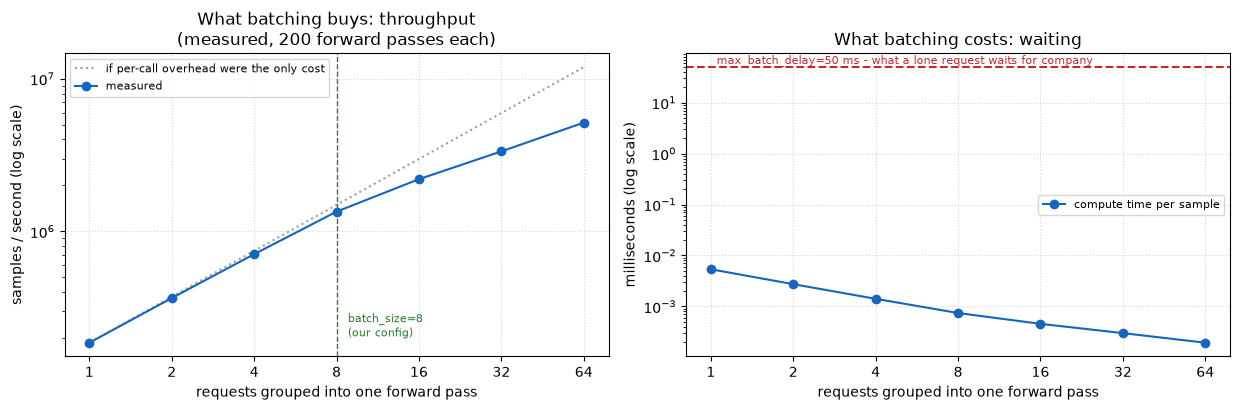

batch    ms / forward pass    ms / sample    samples/s
1        0.005                0.0054              186,299
2        0.005                0.0027              365,505
4        0.006                0.0014              708,853
8        0.006                0.0007            1,346,660
16       0.007                0.0005            2,198,242
32       0.010                0.0003            3,343,419
64       0.012                0.0002            5,160,163

batch 1 -> 64: throughput x27.7, while a request arriving alone can wait up to 50 ms - about 9,315x this model's compute time for one row.


In [6]:
# WHAT: measure what the two knobs in config.properties actually do - run the model
# we just trained at several batch sizes and plot throughput against the price paid
# in waiting, using batch_size and max_batch_delay read back out of that same file.
# WHY: "batching is built-in" is the headline feature of every serving framework, and
# it is a TRADE, not a free win. These are real forward passes of the network above.
import time
from pathlib import Path

import matplotlib.pyplot as plt

# Read the knobs back from the config file written in the cell above - no retyping.
cfg = dict(line.split("=", 1)
           for line in Path("/tmp/config.properties").read_text().splitlines()
           if "=" in line and not line.lstrip().startswith("#"))
CFG_BATCH = int(cfg["batch_size"])
CFG_DELAY_MS = int(cfg["max_batch_delay"])

BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64]
REPEATS = 200

xs = torch.tensor(X_train[:max(BATCH_SIZES)])
model.eval()

per_batch_ms, per_sample_ms, throughput = [], [], []
with torch.no_grad():
    for b in BATCH_SIZES:
        xb = xs[:b]
        for _ in range(20):                       # warm-up: exclude first-call overhead
            model(xb)
        t0 = time.perf_counter()
        for _ in range(REPEATS):
            model(xb)
        dt = (time.perf_counter() - t0) / REPEATS  # seconds per forward pass
        per_batch_ms.append(dt * 1000)
        per_sample_ms.append(dt * 1000 / b)
        throughput.append(b / dt)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
# Dotted reference: what throughput would be if a batch of b cost exactly the same
# as a batch of 1 - i.e. if per-call overhead were the ONLY cost.
ideal = [throughput[0] * b for b in BATCH_SIZES]
ax.plot(BATCH_SIZES, ideal, ":", color="#9e9e9e",
        label="if per-call overhead were the only cost")
ax.plot(BATCH_SIZES, throughput, "o-", color="#1565c0", label="measured")
ax.axvline(CFG_BATCH, ls="--", lw=1, color="#2e7d32")
ax.text(CFG_BATCH * 1.1, min(throughput) * 1.1,
        f"batch_size={CFG_BATCH}\n(our config)", fontsize=8, color="#2e7d32")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.legend(fontsize=8, loc="upper left")
ax.set_xticks(BATCH_SIZES)
ax.set_xticklabels(BATCH_SIZES)
ax.set_xlabel("requests grouped into one forward pass")
ax.set_ylabel("samples / second (log scale)")
ax.set_title(f"What batching buys: throughput\n(measured, {REPEATS} forward passes each)")
ax.grid(ls=":", alpha=0.5)

ax = axes[1]
ax.plot(BATCH_SIZES, per_sample_ms, "o-", color="#1565c0", label="compute time per sample")
ax.axhline(CFG_DELAY_MS, ls="--", lw=1.5, color="#c62828")
ax.text(1.05, CFG_DELAY_MS * 1.15,
        f"max_batch_delay={CFG_DELAY_MS} ms - what a lone request waits for company",
        fontsize=8, color="#c62828")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(BATCH_SIZES)
ax.set_xticklabels(BATCH_SIZES)
ax.set_xlabel("requests grouped into one forward pass")
ax.set_ylabel("milliseconds (log scale)")
ax.set_title("What batching costs: waiting")
ax.legend(fontsize=8, loc="center right")
ax.grid(ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

# The step table behind the two curves.
print(f"{'batch':<8} {'ms / forward pass':<20} {'ms / sample':<14} samples/s")
for b, pb, ps, tp in zip(BATCH_SIZES, per_batch_ms, per_sample_ms, throughput):
    print(f"{b:<8} {pb:<20.3f} {ps:<14.4f} {tp:>12,.0f}")
print(f"\nbatch 1 -> {max(BATCH_SIZES)}: throughput x{throughput[-1] / throughput[0]:.1f}, "
      f"while a request arriving alone can wait up to {CFG_DELAY_MS} ms - about "
      f"{CFG_DELAY_MS / per_batch_ms[0]:,.0f}x this model's compute time for one row.")


**Reading the figure.** *Left, log-log:* every point is a real timed forward pass of the network
trained at the top of this notebook. The dotted line is what throughput would be if grouping
requests were literally free — if a batch of 64 cost the same as a batch of 1. Up to roughly
the `batch_size=8` we put in `config.properties`, the measured line sits **on** that dotted line:
the network is so small that a call is almost entirely fixed overhead, so each doubling of the
batch nearly doubles the samples served. Past 8 the measured line bends away — arithmetic
starts to cost something — and grouping 64 requests bought under 30x, not 64x. That bend is
why `batch_size` has a sweet spot instead of a maximum, and it arrives far earlier on a large
model.

*Right, log axis:* the same batching, priced. The blue line is the compute each sample costs,
and it falls as the batch grows. The red line is `max_batch_delay` from the config file we just
wrote — how long a request that arrives alone will sit in the queue waiting for company. It
sits about four orders of magnitude above the blue line at every batch size. **On a model this
small, batching is not trading compute for compute; it is trading a user's waiting time for
server throughput.** An excellent deal for a nightly GPU workload, an unacceptable one for a
fraud check at checkout — the judgement the "⚠️ Where this breaks" section asks you to make
before touching this knob.

## Part 2 — TensorFlow Serving

TF Serving serves Keras / TensorFlow models saved in the **SavedModel** format. It runs as a Docker container with REST and gRPC endpoints built in.

### Step 1 — Train and Save a Keras Model

In [7]:
# TensorFlow is optional for this notebook (only Part 2 uses it).
#
# Some local TF installs are not merely *missing* but *broken at the native
# (C++) level*: `import tensorflow` aborts the whole Python process (SIGABRT),
# which a normal `try/except ImportError` CANNOT catch — it would kill the
# kernel. So we first probe the import in a short-lived subprocess. Only if
# that subprocess exits cleanly do we import TF into this kernel.
import subprocess, sys

def _tf_import_ok():
    try:
        r = subprocess.run(
            [sys.executable, "-c", "import tensorflow as tf; print(tf.__version__)"],
            capture_output=True, text=True, timeout=180,
        )
        msg = (r.stdout.strip() or r.stderr.strip().splitlines()[-1:] or [""])
        return r.returncode == 0, (r.stdout.strip() if r.returncode == 0 else (r.stderr.strip() or "import failed"))
    except Exception as e:
        return False, str(e)

TF_AVAILABLE, _tf_info = _tf_import_ok()

if TF_AVAILABLE:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
else:
    print("TensorFlow not usable on this machine \u2014 showing code only.")
    print("(This notebook still runs end to end; Part 2 cells print the code/")
    print(" commands instead of executing the Keras model.)")
    last = _tf_info.splitlines()[-1] if _tf_info else "no details"
    print(f"Probe result: {last}")


TensorFlow version: 2.21.0


In [8]:
# WHAT: (if TF is installed) train a small Keras model and export it in the
# SavedModel layout TF Serving requires: <model_name>/<version_number>/.
# WHY: the versioned folder is TF Serving's contract — dropping folder 2/ next
# to 1/ is how you roll out a new version with zero code changes.
if TF_AVAILABLE:
    import tensorflow as tf
    from sklearn.datasets import load_iris
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    import numpy as np

    iris = load_iris()
    scaler = StandardScaler()
    X = scaler.fit_transform(iris.data).astype(np.float32)
    y = tf.keras.utils.to_categorical(iris.target, 3)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Same iris task as the PyTorch half, so the two serving stacks are comparable.
    keras_model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(4,)),
        tf.keras.layers.Dense(3, activation="softmax")
    ])
    keras_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    keras_model.fit(X_train, y_train, epochs=50, verbose=0)

    _, acc = keras_model.evaluate(X_test, y_test, verbose=0)
    print(f"Test accuracy: {acc:.2%}")

    # SavedModel format: version number in the path is required by TF Serving.
    # Keras 3 (TF 2.16+) split saving: model.save() now needs a .keras/.h5
    # extension, and you must use model.export() to write the SavedModel
    # directory that TF Serving loads. Keras 2 (TF <=2.15) used save() for this.
    SAVED_MODEL_PATH = "/tmp/tf_models/iris/1"
    if hasattr(keras_model, "export"):
        keras_model.export(SAVED_MODEL_PATH)   # Keras 3: SavedModel for TF Serving
    else:
        keras_model.save(SAVED_MODEL_PATH)     # Keras 2: save() wrote a SavedModel dir
    print(f"Saved to: {SAVED_MODEL_PATH}")
    print("TF Serving expects: <model_name>/<version_number>/")
else:
    print("TensorFlow not available — review the code above")
    print("SavedModel path format: /tf_models/iris/1/")

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 93.33%


INFO:tensorflow:Assets written to: /tmp/tf_models/iris/1/assets


INFO:tensorflow:Assets written to: /tmp/tf_models/iris/1/assets


Saved artifact at '/tmp/tf_models/iris/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5700634384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5700634960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5700633424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5700635344: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saved to: /tmp/tf_models/iris/1
TF Serving expects: <model_name>/<version_number>/


### Step 2 — Run TF Serving with Docker

TF Serving is distributed as a Docker image. The directory structure matters: `/<model_name>/<version>/` is mandatory.

> **Docker preview** (taught fully in Unit 4): a Docker **image** is a frozen snapshot of an application plus all its dependencies; a **container** is a running instance of one. `docker run` starts a container from an image. The flags below, one by one:
> - `-d` — detached: run in the background
> - `-p 8501:8501` — map port 8501 on your machine to port 8501 inside the container (TF Serving's REST port)
> - `-v /tmp/tf_models:/models` — mount your local model directory into the container so TF Serving can read it
> - `-e MODEL_NAME=iris` — set an environment variable inside the container telling TF Serving which model to load
>
> For now, copy-paste the command as given; Unit 4 notebook 01 teaches you to build and run your own images.

In [9]:
# Shell commands — run in a terminal
tf_serving_commands = """
# 1. Start TF Serving (REST on 8501, gRPC on 8500)
docker run -d \\
    -p 8501:8501 \\
    -v /tmp/tf_models:/models \\
    -e MODEL_NAME=iris \\
    tensorflow/serving

# 2. Check model status
curl http://localhost:8501/v1/models/iris

# 3. Run a prediction (REST API)
curl -X POST http://localhost:8501/v1/models/iris:predict \\
     -H "Content-Type: application/json" \\
     -d '{"instances": [[5.1, 3.5, 1.4, 0.2]]}'

# Expected response:
# {"predictions": [[0.98, 0.01, 0.01]]}
#                  ^ setosa prob is highest

# 4. Query a specific version
curl http://localhost:8501/v1/models/iris/versions/1

# 5. Serve v2 alongside v1 (add another SavedModel to /tmp/tf_models/iris/2/)
# TF Serving detects new versions automatically — no restart needed
"""

print("TF Serving Docker workflow:")
print(tf_serving_commands)

TF Serving Docker workflow:

# 1. Start TF Serving (REST on 8501, gRPC on 8500)
docker run -d \
    -p 8501:8501 \
    -v /tmp/tf_models:/models \
    -e MODEL_NAME=iris \
    tensorflow/serving

# 2. Check model status
curl http://localhost:8501/v1/models/iris

# 3. Run a prediction (REST API)
curl -X POST http://localhost:8501/v1/models/iris:predict \
     -H "Content-Type: application/json" \
     -d '{"instances": [[5.1, 3.5, 1.4, 0.2]]}'

# Expected response:
# {"predictions": [[0.98, 0.01, 0.01]]}
#                  ^ setosa prob is highest

# 4. Query a specific version
curl http://localhost:8501/v1/models/iris/versions/1

# 5. Serve v2 alongside v1 (add another SavedModel to /tmp/tf_models/iris/2/)
# TF Serving detects new versions automatically — no restart needed



### TF Serving Directory Structure

In [10]:
# Show the required directory layout
print("""
TF Serving required directory structure:

/tmp/tf_models/
    iris/                    <- MODEL_NAME (set via -e MODEL_NAME=iris)
        1/                   <- version number (integer)
            saved_model.pb   <- model graph
            variables/       <- model weights
                variables.index
                variables.data-00000-of-00001
        2/                   <- newer version — loaded automatically
            saved_model.pb
            variables/

Key rules:
  - Directory name under <model_name>/ must be an integer (the version)
  - TF Serving serves the HIGHEST version number by default
  - Adding a new numbered directory triggers a hot reload — no restart needed
""")

# Write the structure to disk for reference
import os
os.makedirs("/tmp/tf_models/iris", exist_ok=True)
with open("/tmp/tf_models/iris/README.txt", "w") as f:
    f.write("Place SavedModel directories here as numbered subdirs: 1/, 2/, 3/...")
print("Directory structure written to /tmp/tf_models/iris/")


TF Serving required directory structure:

/tmp/tf_models/
    iris/                    <- MODEL_NAME (set via -e MODEL_NAME=iris)
        1/                   <- version number (integer)
            saved_model.pb   <- model graph
            variables/       <- model weights
                variables.index
                variables.data-00000-of-00001
        2/                   <- newer version — loaded automatically
            saved_model.pb
            variables/

Key rules:
  - Directory name under <model_name>/ must be an integer (the version)
  - TF Serving serves the HIGHEST version number by default
  - Adding a new numbered directory triggers a hot reload — no restart needed

Directory structure written to /tmp/tf_models/iris/


## 💬 Discuss

You have now seen the same model served three ways in this course: raw FastAPI (Unit 1), Flask (notebook 01), and — on paper — a dedicated framework. The comparison table in section 1 lists what the framework adds. Argue about what it costs.

1. The table says batching, versioning, metrics and gRPC come "built-in". For a CPU-only sklearn model answering 5 requests a second, how many of those six rows are worth anything at all? Be specific about which ones you would actually use.
2. TorchServe's archive notice says security patches will not come. You inherit a service running it. List, in order, what you would do in your first week — and justify why "rewrite it on something maintained" is or is not the first item.
3. TF Serving loads the **highest** integer version directory automatically. That means a deploy is a file copy, and a rollback is deleting a directory. Compare that with the explicit registry pointer from notebook 03. Which failure would you rather debug, and which would you rather explain to an auditor?

## 3. When to Use a Dedicated Serving Framework

Use TorchServe or TF Serving when you need:
- **Automatic batching** — collecting concurrent requests and running a single GPU batch
- **A/B testing** — routing 10% of traffic to v2 while v1 handles the rest
- **Multiple models** — one server, many models, each with independent versioning
- **Built-in metrics** — Prometheus metrics at `/metrics` with no extra code

Stick with raw FastAPI when:
- You have 1-2 models and team is already familiar with FastAPI
- You need custom middleware (auth, rate limiting) that's easier to add in Python
- Your model is CPU-only and batching doesn't help

## 4. Summary

In this notebook you:
- Trained a PyTorch model and wrote a custom TorchServe handler with `preprocess`, `inference`, `postprocess`
- Saw the `torch-model-archiver` command that packages model + handler into a `.mar` file
- Trained a Keras model and saved it in TF Serving's required `<model>/<version>/` directory format (if TensorFlow was available in your environment — otherwise you reviewed the exact code that does it)
- Learned the Docker command to start TF Serving and the REST API request format

The key difference from FastAPI: these frameworks handle batching, versioning, and metrics automatically — at the cost of more initial setup.

## Self-Check (answer before scrolling up)

1. **What does the TorchServe handler's `preprocess` method do?** What is it converting, and why is this the handler's responsibility rather than TorchServe's?
2. **What directory structure does TF Serving expect?** Why must the version be an integer directory name?
3. **Name one advantage of TorchServe over raw FastAPI for high-traffic production.** Be specific about which feature provides that advantage.

## ⚠️ Where this breaks

- **A framework's maintenance status is part of its feature set.** TorchServe is archived as of 7 August 2025 with no security patches planned. Everything you learned about handlers and `.mar` archives transfers to other stacks — but do not start a new project on it. Check the repository, the release cadence and the CVE history *before* the architecture diagram, not after.
- **A serving framework adds an attack surface you did not write.** The `config.properties` file you wrote above controls a *management* API — one that can load and unload models. TorchServe shipped for years with that API reachable from every interface by default, and it was exploited (Unit 3 notebook 05 tells that story in full). **Bind management ports to localhost and treat every knob in a framework's config file as a security decision.**
- **Automatic batching helps throughput and hurts latency.** A `batch_delay` of 100 ms means a request arriving alone waits 100 ms for company. That is an excellent trade for GPU inference at volume and a terrible one for a fraud check at checkout. Batching is a knob to be set against an SLO, not a free win.
- **The assumption that must hold:** the handler is where all pre/post-processing lives, and it stays in sync with training. A `.mar` archive freezes the handler with the weights, which is good — until someone changes the feature pipeline upstream and re-archives only the weights.
- **These frameworks do not run in a notebook, and that is a limit on this lesson.** Everything in this notebook is files and commands. You have not seen batching actually batch, or metrics actually emit. Treat this as the map; the territory needs a terminal and a running server.
- **The cheaper alternative.** One or two models, CPU-only, a team fluent in Python: the FastAPI service from Unit 1 with Gunicorn workers is less code, less to patch, and easier to reason about. The threshold that justifies a serving framework is roughly the one section 1 states — many models, GPU batching, or metrics you must expose to an SLA.

## 📚 References

1. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
2. Paszke, A., Gross, S., Massa, F., et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS. <https://arxiv.org/abs/1912.01703>
3. Crankshaw, D., Wang, X., Zhou, G., Franklin, M. J., Gonzalez, J. E., & Stoica, I. (2017). *Clipper: A Low-Latency Online Prediction Serving System*. NSDI. <https://arxiv.org/abs/1612.03079>
